# **DATA ANALYSIS BLINKIT**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('U:/DATA SET/BlinkIT Grocery Data.csv')
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [3]:
print('size of data :',df.shape)

size of data : (8523, 12)


In [4]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

In [3]:
df['Item Fat Content'].unique()

array(['Regular', 'Low Fat', 'low fat', 'LF', 'reg'], dtype=object)

In [4]:
df['Item Fat Content']=df['Item Fat Content'].replace({'low fat':'Low Fat','LF':'Low Fat','reg':'Regular'})
df['Item Fat Content'].unique()

array(['Regular', 'Low Fat'], dtype=object)

## **requirements**

In [5]:
total_sales=df['Sales'].sum().round(1)
total_sales

avg_sales = df['Sales'].mean().round(1)
avg_sales

no_of_items_sold = df['Sales'].count()
no_of_items_sold

avg_rating = df['Rating'].mean().round(2)
avg_rating

np.float64(3.97)

In [6]:
print(f'Total Sales : ${total_sales:,.0f}')
print(f'Avg Sales : ${avg_sales:}')
print(f'No_Of_Items Sold :{no_of_items_sold:,}')
print(f'Avg Rating :{avg_rating:}')

Total Sales : $1,201,682
Avg Sales : $141.0
No_Of_Items Sold :8,523
Avg Rating :3.97


## **total sales by fat content**

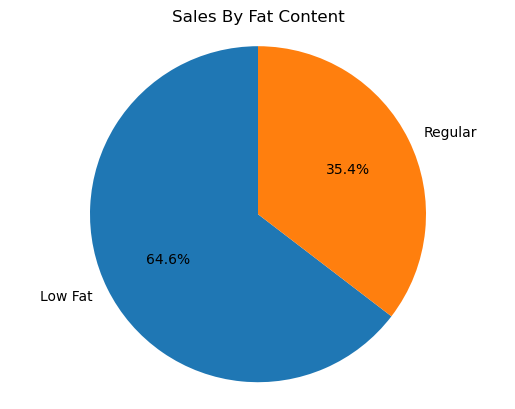

In [7]:
sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum()
plt.pie(sales_by_fat,labels=sales_by_fat.index,autopct='%.1f%%',startangle=90)
plt.title('Sales By Fat Content')
plt.axis('equal')
plt.show()

## **total sales by item type**

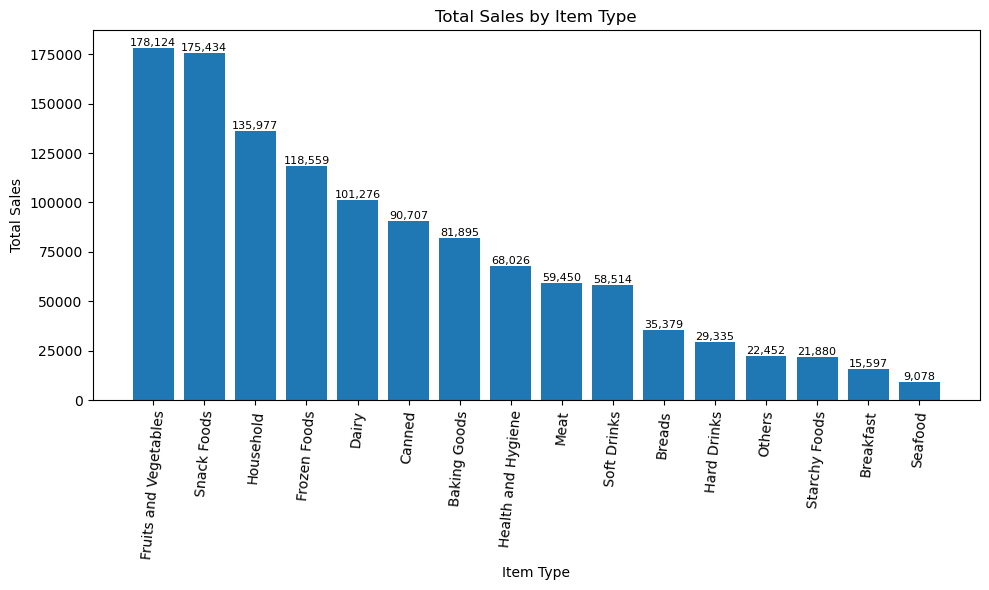

In [21]:
sales_by_type = df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False) 

plt.figure(figsize=(10,6))
bars=plt.bar(sales_by_type.index,sales_by_type.values)

plt.xticks(rotation=85)
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.title('Total Sales by Item Type')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,bar.get_height(),
            f'{bar.get_height():,.0f}',ha='center',va='bottom',fontsize=8)
plt.tight_layout()
plt.show()

# fat content by outlet for total sales

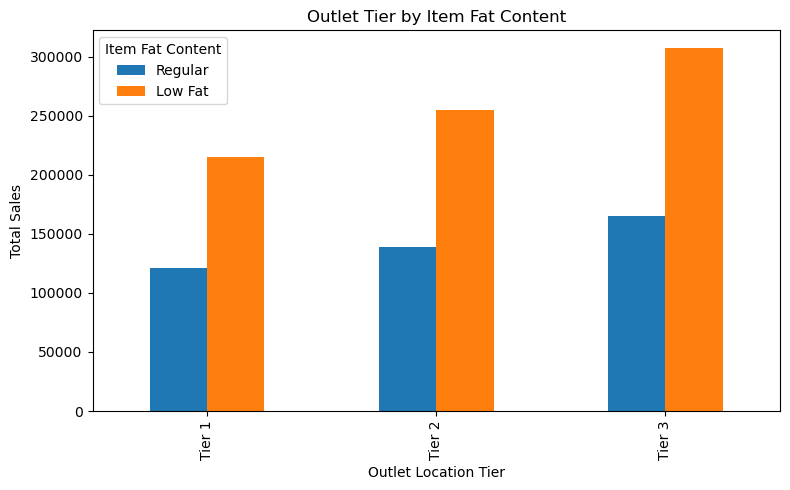

In [26]:
grouped=df.groupby(['Outlet Location Type','Item Fat Content'])['Sales'].sum().unstack()
grouped=grouped[['Regular','Low Fat']]

ax=grouped.plot(kind='bar',figsize=(8,5),title='Outlet Tier by Item Fat Content')
plt.xlabel('Outlet Location Tier')
plt.ylabel('Total Sales')
plt.legend(title='Item Fat Content')
plt.tight_layout()
plt.show()

# total sales by outlet establishment

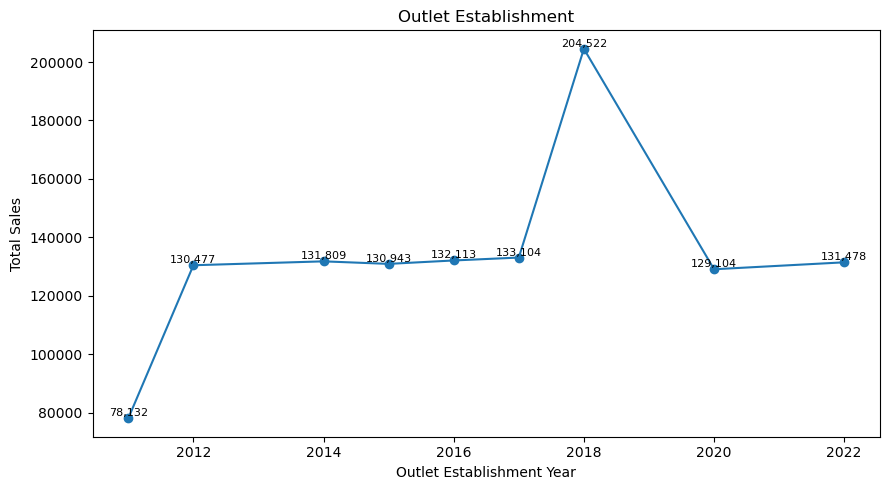

In [32]:
sales_by_year = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()

plt.figure(figsize=(9,5))
plt.plot(sales_by_year.index,sales_by_year.values,marker='o',linestyle='-')

plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment')

for x,y in zip(sales_by_year.index,sales_by_year.values):
    plt.text(x,y,f'{y:,.0f}',ha='center',va='bottom',fontsize=8)

plt.tight_layout()
plt.show()

# sales by outlet size

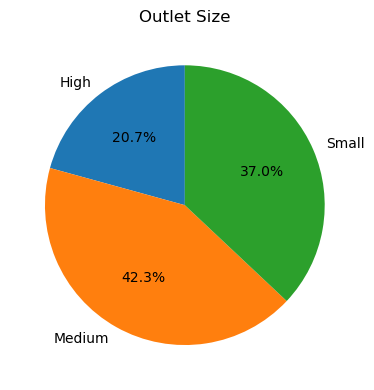

In [3]:
sales_by_size = df.groupby('Outlet Size')['Sales'].sum()
plt.figure(figsize=(4,4))
plt.pie(sales_by_size,labels=sales_by_size.index,autopct='%1.1f%%',startangle=90)
plt.title('Outlet Size')
plt.tight_layout()
plt.show()

# sales by outlet location

<function matplotlib.pyplot.show(close=None, block=None)>

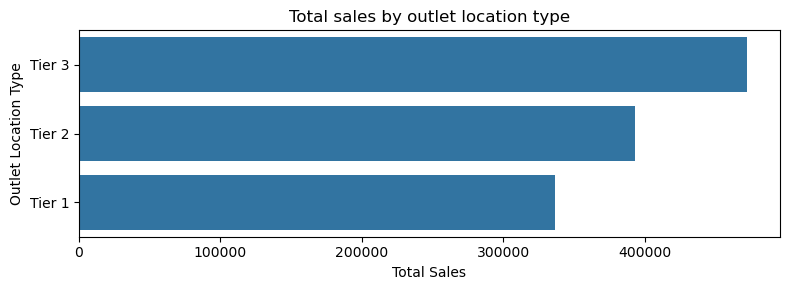

In [6]:
sales_by_location = df.groupby('Outlet Location Type')['Sales'].sum().reset_index()
sales_by_location=sales_by_location.sort_values('Sales',ascending=False)

plt.figure(figsize=(8,3))
ax=sns.barplot(x='Sales',y='Outlet Location Type',data=sales_by_location)
plt.xlabel('Total Sales')
plt.ylabel('Outlet Location Type')
plt.title('Total sales by outlet location type')
plt.tight_layout()
plt.show